# Analyse exploratoire visuelle des marchés publics

Chaque graphique de ce notebook est produit ici, sous vos yeux : la requête qui extrait les données,
puis le code qui les trace. Rien n'est importé d'ailleurs.

Les mêmes figures existent en version de production dans `mesures/figures.py`, qui les écrit en SVG
et en PNG pour le mémoire, à partir des CSV de `mesures/resultats/`. Ce notebook est le brouillon
qui a servi à les concevoir ; le script est la version reproductible.

**Périmètre** : l'état actuel de chaque marché, soit 2 114 675 lignes pour 1 833 468 marchés
distincts. Une ligne par titulaire : un marché attribué à trois entreprises occupe trois lignes.

## Préparation

Seules les constantes de style sont importées, pour que les quinze figures se ressemblent :
la palette validée, les couleurs de texte et les deux fonctions qui retirent le décor inutile.
Tout le reste, requêtes et tracés, est écrit ici.

In [1]:
import sys

sys.path.append("..")

import duckdb
import matplotlib.pyplot as plt

from mesures.figures import (
    ENCRE,  # couleur du texte, jamais d'une série
    FILET,  # grille discrète
    GRIS,  # texte secondaire
    RAMPE_BLEUE,  # rampe séquentielle : une teinte, du clair au foncé
    SERIE_1,  # bleu ardoise
    SERIE_2,  # terre de Sienne
    SERIE_4,  # prune
    legender,  # légende sous la figure : source, périmètre, unité
    soigner,  # retire le cadre, allège la grille, pose le titre
)

# mesures.figures choisit le mode sans fenetre, utile pour un script. Dans un notebook, on
# redemande l'affichage en ligne, sinon les graphiques seraient traces et jamais montres.
%matplotlib inline

con = duckdb.connect()
con.register("decp", con.read_parquet("../donnees/brut/decp.parquet"))
con.execute("create or replace view marches as select * from decp where donneesActuelles")

lignes = con.sql("select count(*) from marches").fetchone()[0]
marches = con.sql("select count(distinct uid) from marches").fetchone()[0]
print(f"{lignes:,} lignes pour {marches:,} marchés".replace(",", " "))

2 114 675 lignes pour 1 833 468 marchés


## 1. Le problème, en une image

**Question** : la somme des montants déclarés est-elle utilisable telle quelle ?

In [2]:
total_annuel = con.sql("""
    select
        year(dateNotification)       as annee,
        round(sum(montant) / 1e9, 1) as brut,
        round(sum(case when montant_anomalie is null then montant else 0 end) / 1e9, 1)
            as nettoye
    from marches
    where dateNotification between date '2019-01-01' and date '2025-12-31'
    group by 1
    order by 1
""").df()
total_annuel

,annee,brut,nettoye
0,2019,267.6,57.0
1,2020,3030.2,113.3
2,2021,3157.9,243.7
3,2022,2511.3,196.4
4,2023,1988.2,256.5
5,2024,2071.0,236.2
6,2025,4724.8,258.3


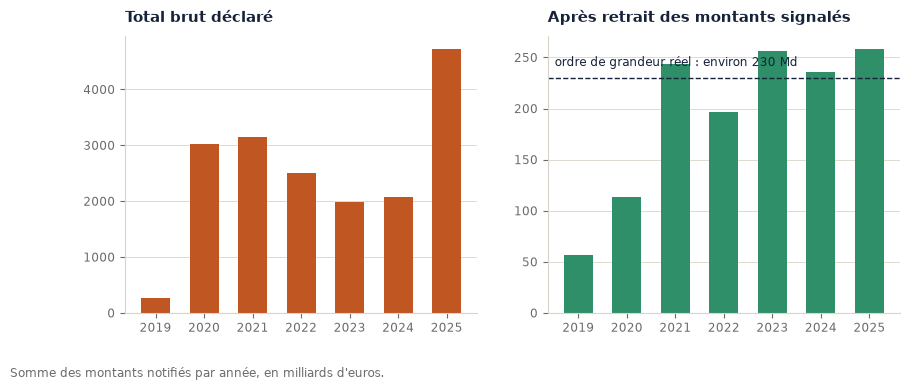

In [3]:
# Deux panneaux plutôt qu'un seul : à la même échelle, la série nettoyée serait écrasée contre
# l'axe et deviendrait illisible. Deux échelles superposées dans un seul cadre seraient pires
# encore, c'est l'erreur de lecture la plus fréquente en visualisation.
figure, (gauche, droite) = plt.subplots(1, 2, figsize=(10, 3.6))

gauche.bar(total_annuel["annee"].astype(str), total_annuel["brut"], color=SERIE_2, width=0.6)
soigner(gauche, "Total brut déclaré")

droite.bar(total_annuel["annee"].astype(str), total_annuel["nettoye"], color="#2f8f68", width=0.6)
droite.axhline(230, color=ENCRE, linewidth=1, linestyle="--")
droite.text(
    0.02,
    0.88,
    "ordre de grandeur réel : environ 230 Md",
    transform=droite.transAxes,
    color=ENCRE,
    fontsize=8.5,
    va="bottom",
)
soigner(droite, "Après retrait des montants signalés")

legender(figure, "Somme des montants notifiés par année, en milliards d'euros.")
plt.show()

**Ce qu'on y lit** : 3 030 milliards d'euros annoncés pour 2020, 4 725 pour 2025, contre environ
230 milliards réels. Écarter les lignes que le producteur signale déjà comme suspectes ou aberrantes
suffit à revenir dans le bon ordre de grandeur.

**Ce qu'elle ne dit pas** : que les données seraient falsifiées. Elles sont déclaratives, saisies par
des milliers d'agents dans des dizaines de logiciels. Le problème est l'absence de contrôle à la
saisie, pas la malveillance.

**Ce que ça change** : le nettoyage n'est pas un préalable technique, c'est le produit lui-même.

## 2. La forme des montants

**Question** : quelle loi suivent les montants ? La réponse décide de la méthode de détection.

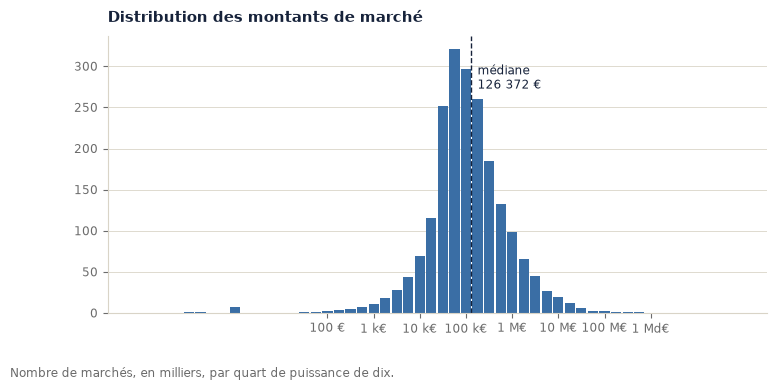

In [4]:
histogramme = con.sql("""
    select
        floor(log10(montant) * 4) / 4 as puissance,
        count(*)                      as marches
    from marches
    where montant > 0
    group by 1
    having count(*) > 20
    order by 1
""").df()

figure, axes = plt.subplots(figsize=(8.5, 3.6))
axes.bar(histogramme["puissance"], histogramme["marches"] / 1000, width=0.22, color=SERIE_1)
axes.axvline(5.1, color=ENCRE, linewidth=1, linestyle="--")
axes.text(
    5.25,
    histogramme["marches"].max() / 1000 * 0.85,
    "médiane\n126 372 €",
    color=ENCRE,
    fontsize=8.5,
)
axes.set_xticks([2, 3, 4, 5, 6, 7, 8, 9])
axes.set_xticklabels(["100 €", "1 k€", "10 k€", "100 k€", "1 M€", "10 M€", "100 M€", "1 Md€"])
soigner(axes, "Distribution des montants de marché")
legender(figure, "Nombre de marchés, en milliers, par quart de puissance de dix.")
plt.show()

**Ce qu'on y lit** : une cloche presque symétrique une fois l'axe passé en logarithme, signature
d'une loi log-normale. En échelle linéaire, 99 % des marchés seraient empilés sur la première barre.

**Ce que ça change** : un écart anormal se mesurera sur le **logarithme** du montant. Travailler sur
le montant brut donnerait un poids absurde aux quelques très gros marchés.

## 3. Le temps : saisonnalité et tendance

**Question** : la commande publique suit-elle le calendrier budgétaire, et ce motif est-il stable ?

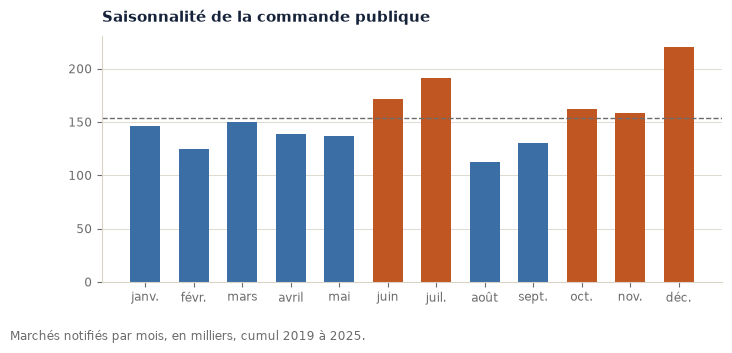

In [5]:
saison = con.sql("""
    select month(dateNotification) as mois, count(*) as marches
    from marches
    where dateNotification between date '2019-01-01' and date '2025-12-31'
    group by 1 order by 1
""").df()

mois_noms = [
    "janv.",
    "févr.",
    "mars",
    "avril",
    "mai",
    "juin",
    "juil.",
    "août",
    "sept.",
    "oct.",
    "nov.",
    "déc.",
]
moyenne = saison["marches"].mean()
# La couleur chaude ne décore pas : elle désigne les mois au-dessus de la moyenne, qui sont le
# message de la figure.
couleurs = [SERIE_2 if v > moyenne else SERIE_1 for v in saison["marches"]]

figure, axes = plt.subplots(figsize=(8, 3.2))
axes.bar(mois_noms, saison["marches"] / 1000, color=couleurs, width=0.62)
axes.axhline(moyenne / 1000, color=GRIS, linewidth=1, linestyle="--")
soigner(axes, "Saisonnalité de la commande publique")
legender(figure, "Marchés notifiés par mois, en milliers, cumul 2019 à 2025.")
plt.show()

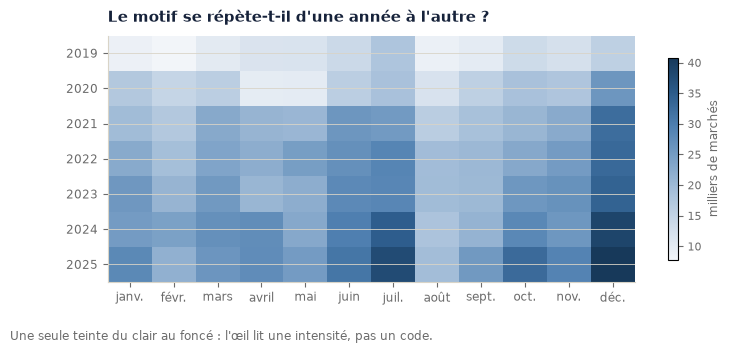

In [6]:
# Une moyenne peut cacher une année atypique. La carte de chaleur vérifie que le motif se répète.
grille = (
    con.sql("""
    select year(dateNotification) as annee, month(dateNotification) as mois, count(*) as marches
    from marches
    where dateNotification between date '2019-01-01' and date '2025-12-31'
    group by 1, 2 order by 1, 2
""")
    .df()
    .pivot(index="annee", columns="mois", values="marches")
)

figure, axes = plt.subplots(figsize=(8.5, 3.2))
image = axes.imshow(grille / 1000, cmap=RAMPE_BLEUE, aspect="auto")
axes.set_xticks(range(12), mois_noms)
axes.set_yticks(range(len(grille.index)), [str(a) for a in grille.index])
axes.grid(visible=False)
barre = figure.colorbar(image, ax=axes, shrink=0.82)
barre.set_label("milliers de marchés", color=GRIS, fontsize=8.5)
barre.ax.tick_params(colors=GRIS, labelsize=8)
soigner(axes, "Le motif se répète-t-il d'une année à l'autre ?")
legender(figure, "Une seule teinte du clair au foncé : l'œil lit une intensité, pas un code.")
plt.show()

**Ce qu'on y lit** : décembre et juillet ressortent chaque année, août est creux. Le motif est
stable : c'est un effet de calendrier budgétaire, pas l'accident d'une année.

**Ce que ça change** : la détection comparera un marché à ses pairs **du même mois**. Sinon chaque
décembre serait signalé comme anormal.

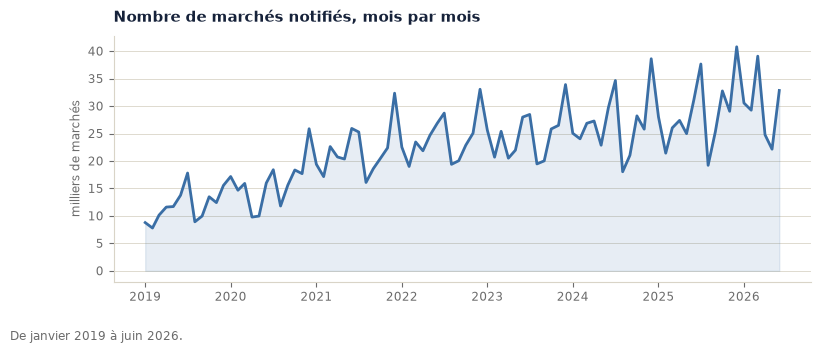

In [7]:
evolution = con.sql("""
    select date_trunc('month', dateNotification) as mois, count(*) as marches
    from marches
    where dateNotification between date '2019-01-01' and date '2026-06-30'
    group by 1 order by 1
""").df()

figure, axes = plt.subplots(figsize=(9, 3.2))
axes.plot(evolution["mois"], evolution["marches"] / 1000, color=SERIE_1, linewidth=2)
axes.fill_between(evolution["mois"], evolution["marches"] / 1000, color=SERIE_1, alpha=0.12)
axes.set_ylabel("milliers de marchés", color=GRIS, fontsize=8.5)
soigner(axes, "Nombre de marchés notifiés, mois par mois")
legender(figure, "De janvier 2019 à juin 2026.")
plt.show()

**Attention au piège** : cette hausse mélange l'activité réelle et l'élargissement de la collecte,
qui agrège aujourd'hui 63 sources contre bien moins en 2019. **Un chiffre qui monte dans un jeu
agrégé ne prouve pas que le phénomène augmente.** C'est l'erreur qui a fait dériver Google Flu
Trends. À vérifier source par source avant toute interprétation.

## 4. Qui achète

**Question** : peut-on comparer les montants de deux acheteurs sans tenir compte de leur nature ?

In [8]:
quartiles = con.sql("""
    select
        acheteur_categorie                      as categorie,
        count(*)                                as marches,
        round(quantile_cont(montant, 0.05), 0)  as bas,
        round(quantile_cont(montant, 0.25), 0)  as q1,
        round(median(montant), 0)               as mediane,
        round(quantile_cont(montant, 0.75), 0)  as q3,
        round(quantile_cont(montant, 0.95), 0)  as haut
    from marches
    where montant > 0 and acheteur_categorie is not null and montant_anomalie is null
    group by 1 having count(*) > 20000
    order by mediane
""").df()
quartiles

,categorie,marches,bas,q1,mediane,q3,haut
0,Établissement hospitalier,115098,1283.0,28350.0,100000.0,369234.0,3000000.0
1,Commune,649925,7600.0,48709.0,100000.0,253283.0,1200000.0
2,État,51469,2756.0,30800.0,105494.0,400000.0,3640322.0
3,EPIC,143944,6313.0,41069.0,108000.0,300731.0,2000000.0
4,Groupement de communes,338258,13887.0,60000.0,150000.0,453711.0,2964316.0
5,Département,179124,15000.0,68378.0,194300.0,698295.0,4800000.0
6,Syndicat mixte,85871,17369.0,72250.0,199365.0,715685.0,7961982.0
7,Région,50115,7422.0,66000.0,208000.0,900072.0,7488257.0


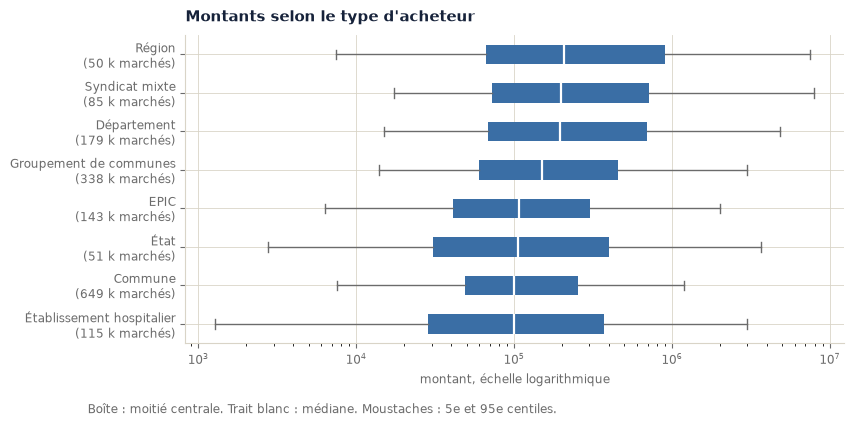

In [9]:
# Les quartiles sont calculés en SQL sur 2 millions de lignes, puis dessinés ici. Faire remonter
# les montants un par un dans Python pour que matplotlib recalcule les quantiles serait absurde :
# c'est le moteur de données qui sait faire ça vite.
boites = [
    {
        "label": f"{r.categorie}\n({r.marches // 1000} k marchés)",
        "whislo": r.bas,
        "q1": r.q1,
        "med": r.mediane,
        "q3": r.q3,
        "whishi": r.haut,
        "fliers": [],
    }
    for r in quartiles.itertuples()
]

figure, axes = plt.subplots(figsize=(8.5, 4))
axes.bxp(
    boites,
    orientation="horizontal",
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": SERIE_1, "edgecolor": SERIE_1, "linewidth": 0},
    medianprops={"color": "white", "linewidth": 1.6},
    whiskerprops={"color": GRIS, "linewidth": 1},
    capprops={"color": GRIS, "linewidth": 1},
)
axes.set_xscale("log")
axes.set_xlabel("montant, échelle logarithmique", color=GRIS, fontsize=8.5)
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
soigner(axes, "Montants selon le type d'acheteur")
legender(figure, "Boîte : moitié centrale. Trait blanc : médiane. Moustaches : 5e et 95e centiles.")
plt.show()

**Ce qu'on y lit** : régions, syndicats mixtes et départements médianent autour de 200 000 euros,
soit le double des communes et de l'État, à 100 000 euros. L'État se distingue par sa dispersion,
la plus large de toutes.

**Ce que ça change** : le prix « normal » dépend de qui achète autant que de ce qui est acheté.

## 5. Où sont les acheteurs

**Question** : peut-on fonder une recherche par territoire, et faut-il un fond de carte pour cela ?

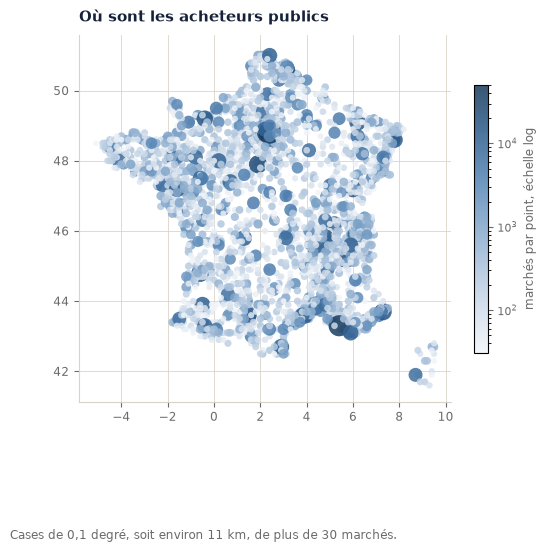

In [10]:
geo = con.sql("""
    select round(acheteur_latitude, 1) as lat, round(acheteur_longitude, 1) as lon,
           count(*) as marches
    from marches
    where acheteur_latitude between 41 and 52 and acheteur_longitude between -5.5 and 9.8
    group by 1, 2 having count(*) > 30
""").df()

from matplotlib.colors import LogNorm  # noqa: E402

figure, axes = plt.subplots(figsize=(6, 5.8))
# Échelle logarithmique pour la couleur : Paris dépasse 50 000 marchés quand la case médiane en
# compte une centaine. En échelle linéaire, la France entière serait blanche.
nuage = axes.scatter(
    geo["lon"],
    geo["lat"],
    s=12 + 240 * (geo["marches"] / geo["marches"].max()) ** 0.5,
    c=geo["marches"],
    cmap=RAMPE_BLEUE,
    norm=LogNorm(vmin=geo["marches"].min(), vmax=geo["marches"].max()),
    alpha=0.85,
    linewidths=0,
)
barre = figure.colorbar(nuage, ax=axes, shrink=0.6)
barre.set_label("marchés par point, échelle log", color=GRIS, fontsize=8.5)
barre.ax.tick_params(colors=GRIS, labelsize=8)
axes.set_aspect(1 / 0.66)
axes.grid(color=FILET, linewidth=0.6)
soigner(axes, "Où sont les acheteurs publics")
legender(figure, "Cases de 0,1 degré, soit environ 11 km, de plus de 30 marchés.")
plt.show()

**Ce qu'on y lit** : la forme du territoire apparaît par la seule densité des acheteurs, sans aucun
fond de carte ni jeu de données géographique supplémentaire.

**Ce que ça change** : une dépendance de moins, et la preuve que la recherche par territoire a du
sens.

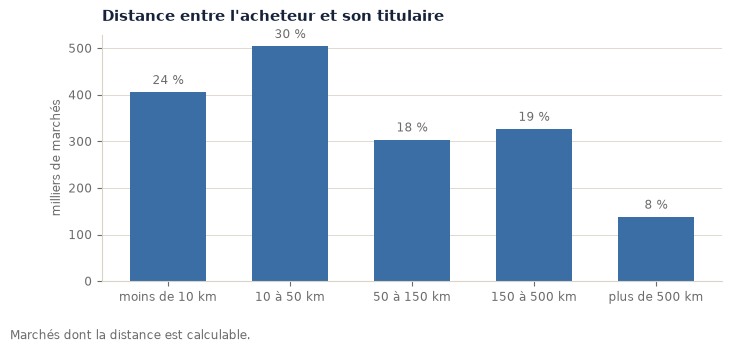

In [11]:
distance = con.sql("""
    select
        case
            when titulaire_distance < 10  then 'moins de 10 km'
            when titulaire_distance < 50  then '10 à 50 km'
            when titulaire_distance < 150 then '50 à 150 km'
            when titulaire_distance < 500 then '150 à 500 km'
            else                               'plus de 500 km'
        end      as tranche,
        count(*) as marches
    from marches
    where titulaire_distance is not null
    group by 1 order by min(titulaire_distance)
""").df()

figure, axes = plt.subplots(figsize=(8, 3.2))
barres = axes.bar(distance["tranche"], distance["marches"] / 1000, color=SERIE_1, width=0.62)
part = 100 * distance["marches"] / distance["marches"].sum()
axes.bar_label(barres, labels=[f"{p:.0f} %" for p in part], padding=4, color=GRIS, fontsize=8.5)
axes.set_ylabel("milliers de marchés", color=GRIS, fontsize=8.5)
soigner(axes, "Distance entre l'acheteur et son titulaire")
legender(figure, "Marchés dont la distance est calculable.")
plt.show()

**Ce qu'on y lit** : plus de la moitié des marchés sont attribués à moins de 50 km. La commande
publique est largement un fait local.

**Ce que ça change** : c'est l'argument central du service pour une PME. Et pour la détection, la
proximité n'est pas suspecte : c'est la norme.

## 6. Ce qu'on achète

**Question** : les familles d'achat sont-elles comparables entre elles ?

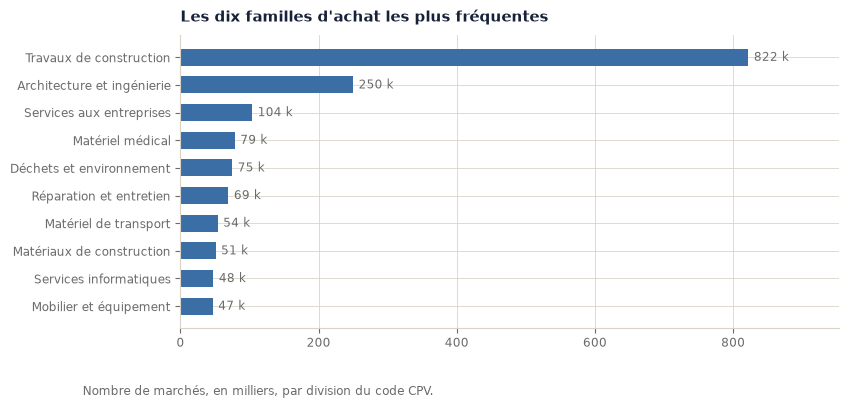

In [12]:
cpv = con.sql("""
    select substr(codeCPV, 1, 2) as famille, count(*) as marches
    from marches where codeCPV is not null
    group by 1 order by marches desc limit 10
""").df()

noms = {
    "45": "Travaux de construction",
    "71": "Architecture et ingénierie",
    "79": "Services aux entreprises",
    "33": "Matériel médical",
    "90": "Déchets et environnement",
    "50": "Réparation et entretien",
    "34": "Matériel de transport",
    "44": "Matériaux de construction",
    "72": "Services informatiques",
    "39": "Mobilier et équipement",
}

figure, axes = plt.subplots(figsize=(8.5, 3.8))
barres = axes.barh(
    [noms.get(f, f"Division {f}") for f in cpv["famille"]],
    cpv["marches"] / 1000,
    color=SERIE_1,
    height=0.62,
)
axes.bar_label(barres, fmt="%.0f k", padding=4, color=GRIS, fontsize=8.5)
axes.invert_yaxis()
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
axes.set_xlim(0, cpv["marches"].max() / 1000 * 1.16)
soigner(axes, "Les dix familles d'achat les plus fréquentes")
legender(figure, "Nombre de marchés, en milliers, par division du code CPV.")
plt.show()

**Ce qu'on y lit** : la construction représente plus du triple de la famille suivante.

**Ce que ça change** : toute comparaison de prix se fera à l'intérieur d'une famille. Un marché de
voirie et un marché de logiciels n'ont rien de comparable.

## 7. Ce qui est utilisable, et ce qui ne l'est pas

**Question** : sur quels champs peut-on réellement bâtir un indicateur ?

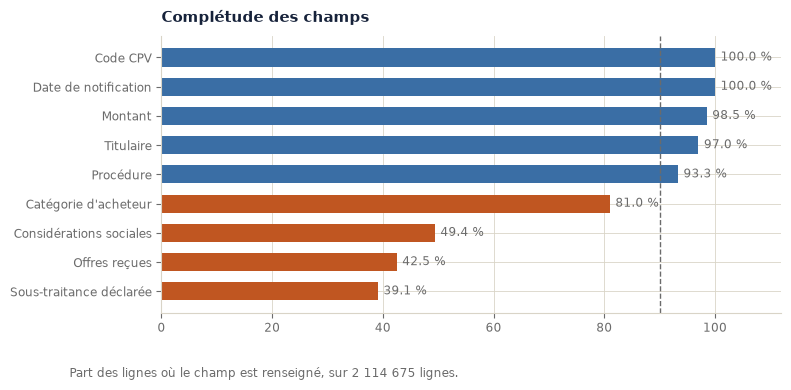

In [13]:
completude = con.sql("""
    select champ, round(100.0 * renseignes / total, 1) as part
    from (
        select 'Montant' as champ, count(montant) as renseignes, count(*) as total from marches
        union all select 'Date de notification', count(dateNotification), count(*) from marches
        union all select 'Code CPV', count(codeCPV), count(*) from marches
        union all select 'Titulaire', count(titulaire_id), count(*) from marches
        union all select 'Catégorie d''acheteur', count(acheteur_categorie), count(*) from marches
        union all select 'Procédure', count(procedure), count(*) from marches
        union all select 'Considérations sociales', count(considerationsSociales), count(*)
            from marches
        union all select 'Offres reçues', count(offresRecues), count(*) from marches
        union all select 'Sous-traitance déclarée', count(sousTraitanceDeclaree), count(*)
            from marches
    ) order by part
""").df()

# Le seuil de 90 % sépare ce qui est directement exploitable de ce qui demande une précaution.
couleurs = [SERIE_1 if p >= 90 else SERIE_2 for p in completude["part"]]

figure, axes = plt.subplots(figsize=(8, 3.6))
barres = axes.barh(completude["champ"], completude["part"], color=couleurs, height=0.62)
axes.bar_label(barres, fmt="%.1f %%", padding=4, color=GRIS, fontsize=8.5)
axes.axvline(90, color=GRIS, linewidth=1, linestyle="--")
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
axes.set_xlim(0, 112)
soigner(axes, "Complétude des champs")
legender(figure, "Part des lignes où le champ est renseigné, sur 2 114 675 lignes.")
plt.show()

**Ce qu'on y lit** : identifiants et dates sont complets, les montants à 98,5 %. Mais la
sous-traitance, les considérations sociales et le nombre d'offres manquent dans plus d'un cas sur
deux.

**Ce que ça change** : cette figure décide de ce qui est faisable. Un indicateur bâti sur un champ
rempli à 39 % ne mesure pas le phénomène, il mesure qui remplit le formulaire.

## 8. La concurrence

**Question** : l'indicateur de risque le plus utilisé de la littérature est-il exploitable ici ?

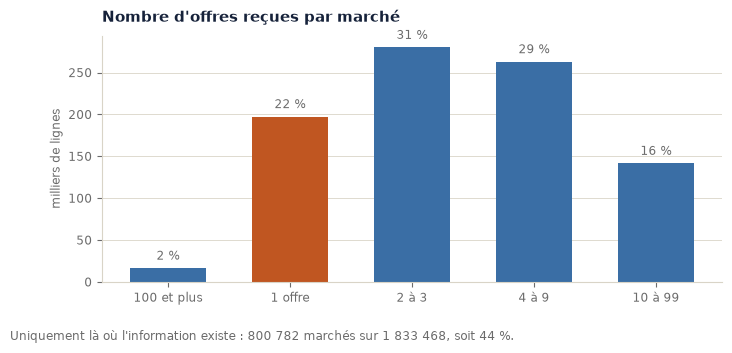

In [14]:
offres = con.sql("""
    select
        case
            when offresRecues = 1               then '1 offre'
            when offresRecues between 2 and 3   then '2 à 3'
            when offresRecues between 4 and 9   then '4 à 9'
            when offresRecues between 10 and 99 then '10 à 99'
            else                                     '100 et plus'
        end      as tranche,
        count(*) as marches
    from marches where offresRecues is not null
    group by 1 order by min(offresRecues)
""").df()

couleurs = [SERIE_2 if t == "1 offre" else SERIE_1 for t in offres["tranche"]]
part = 100 * offres["marches"] / offres["marches"].sum()

figure, axes = plt.subplots(figsize=(8, 3.2))
barres = axes.bar(offres["tranche"], offres["marches"] / 1000, color=couleurs, width=0.62)
axes.bar_label(barres, labels=[f"{p:.0f} %" for p in part], padding=4, color=GRIS, fontsize=8.5)
axes.set_ylabel("milliers de lignes", color=GRIS, fontsize=8.5)
soigner(axes, "Nombre d'offres reçues par marché")
legender(
    figure, "Uniquement là où l'information existe : 800 782 marchés sur 1 833 468, soit 44 %."
)
plt.show()

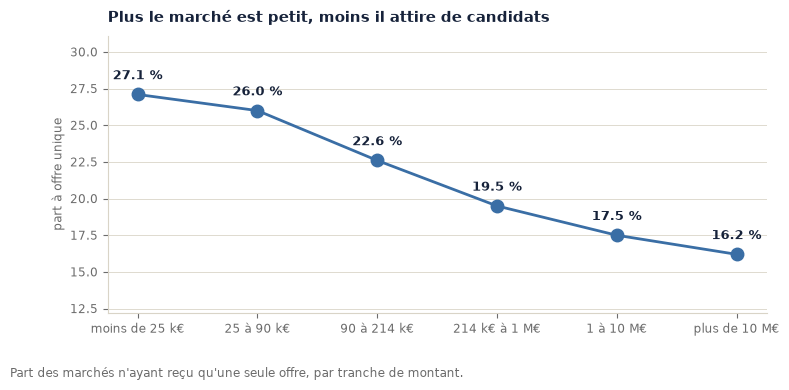

In [15]:
par_tranche = con.sql("""
    select
        case
            when montant < 25000    then 'moins de 25 k€'
            when montant < 90000    then '25 à 90 k€'
            when montant < 214000   then '90 à 214 k€'
            when montant < 1000000  then '214 k€ à 1 M€'
            when montant < 10000000 then '1 à 10 M€'
            else                         'plus de 10 M€'
        end as tranche,
        count(*) as marches,
        round(100.0 * sum(case when offresRecues = 1 then 1 else 0 end) / count(*), 1) as part
    from marches
    where montant > 0 and offresRecues is not null and montant_anomalie is null
    group by 1 order by min(montant)
""").df()

# Une ligne, et non des barres : les tranches sont ordonnées, et c'est la pente qui porte le sens.
figure, axes = plt.subplots(figsize=(8.5, 3.6))
axes.plot(
    par_tranche["tranche"],
    par_tranche["part"],
    color=SERIE_1,
    linewidth=2,
    marker="o",
    markersize=9,
)
for x, ligne in enumerate(par_tranche.itertuples()):
    axes.annotate(
        f"{ligne.part:.1f} %",
        xy=(x, ligne.part),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        color=ENCRE,
        fontsize=9,
        fontweight="bold",
    )
axes.set_ylim(par_tranche["part"].min() - 4, par_tranche["part"].max() + 4)
axes.set_ylabel("part à offre unique", color=GRIS, fontsize=8.5)
soigner(axes, "Plus le marché est petit, moins il attire de candidats")
legender(figure, "Part des marchés n'ayant reçu qu'une seule offre, par tranche de montant.")
plt.show()

**Ce qu'on y lit** : 22 % des marchés renseignés n'ont reçu qu'une offre, et cette part décroît
régulièrement avec le montant, de 27,1 % à 16,2 %.

**Ce que ça change** : le signal utile n'est pas « une seule offre », mais **l'écart au comportement
attendu de sa tranche**. Une offre unique sur un petit marché de voirie communale est banale ; sur
un marché à dix millions, beaucoup moins.

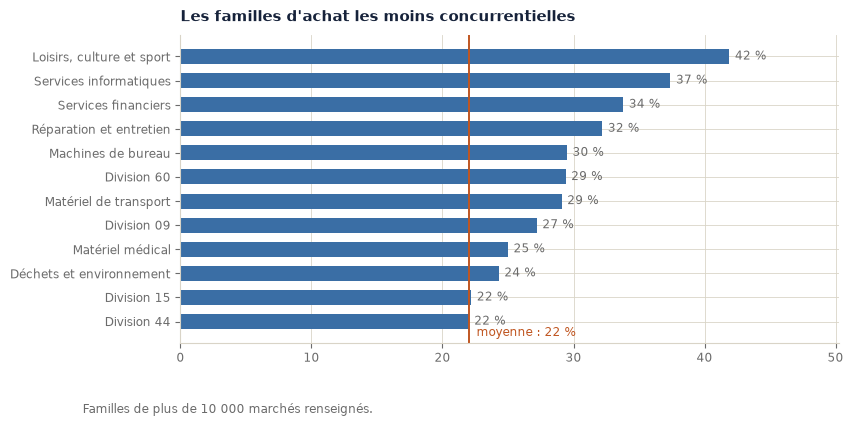

In [16]:
par_cpv = con.sql("""
    select substr(codeCPV, 1, 2) as famille, count(*) as marches,
           round(100.0 * sum(case when offresRecues = 1 then 1 else 0 end) / count(*), 1) as part
    from marches
    where offresRecues is not null and codeCPV is not null
    group by 1 having count(*) > 10000
    order by part desc limit 12
""").df()

noms_cpv = {
    "92": "Loisirs, culture et sport",
    "72": "Services informatiques",
    "66": "Services financiers",
    "50": "Réparation et entretien",
    "30": "Machines de bureau",
    "48": "Logiciels",
    "79": "Services aux entreprises",
    "34": "Matériel de transport",
    "45": "Travaux de construction",
    "71": "Architecture et ingénierie",
    "33": "Matériel médical",
    "90": "Déchets et environnement",
    "31": "Appareils électriques",
    "35": "Équipements de sécurité",
    "80": "Enseignement",
    "85": "Santé et social",
}

figure, axes = plt.subplots(figsize=(8.5, 4))
barres = axes.barh(
    [noms_cpv.get(f, f"Division {f}") for f in par_cpv["famille"]],
    par_cpv["part"],
    color=SERIE_1,
    height=0.62,
)
axes.bar_label(barres, fmt="%.0f %%", padding=4, color=GRIS, fontsize=8.5)
axes.axvline(22, color=SERIE_2, linewidth=1.4)
axes.text(22.6, len(par_cpv) - 0.4, "moyenne : 22 %", color=SERIE_2, fontsize=8.5)
axes.invert_yaxis()
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
axes.set_xlim(0, par_cpv["part"].max() * 1.2)
soigner(axes, "Les familles d'achat les moins concurrentielles")
legender(figure, "Familles de plus de 10 000 marchés renseignés.")
plt.show()

**Ce qu'on y lit** : les services informatiques atteignent 37,4 % d'offre unique, contre 22 % en
moyenne.

**Ce qu'elle ne dit pas** : que ces marchés seraient irréguliers. Un marché très spécialisé attire
peu de candidats. **Un indicateur de risque n'est pas une accusation**, c'est une invitation à
regarder. C'est la limite que pose la littérature elle-même, et le service devra l'écrire à l'écran.

## 9. La concentration

**Question** : la commande publique est-elle répartie, ou captée par quelques entreprises ?

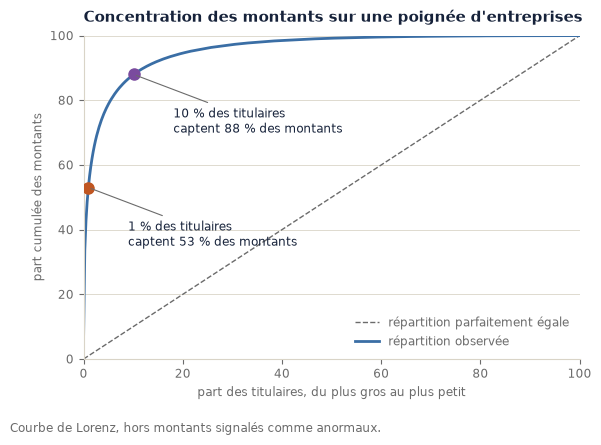

In [17]:
lorenz = con.sql("""
    with par_titulaire as (
        select titulaire_id, sum(montant) as total
        from marches
        where montant > 0 and montant_anomalie is null and titulaire_id is not null
        group by 1
    ),
    classe as (
        select
            row_number() over (order by total desc) as rang,
            count(*) over ()                        as titulaires,
            sum(total) over ()                      as montant_total,
            sum(total) over (order by total desc
                             rows between unbounded preceding and current row) as cumul
        from par_titulaire
    )
    select round(100.0 * rang / titulaires, 2)     as part_titulaires,
           round(100.0 * cumul / montant_total, 2) as part_montants
    from classe
    where rang % 500 = 0 or rang <= 10
    order by rang
""").df()

figure, axes = plt.subplots(figsize=(6.4, 4.2))
axes.plot(
    [0, 100],
    [0, 100],
    color=GRIS,
    linewidth=1,
    linestyle="--",
    label="répartition parfaitement égale",
)
axes.plot(
    lorenz["part_titulaires"],
    lorenz["part_montants"],
    color=SERIE_1,
    linewidth=2,
    label="répartition observée",
)

for seuil, couleur in ((1.0, SERIE_2), (10.0, SERIE_4)):
    point = lorenz.iloc[(lorenz["part_titulaires"] - seuil).abs().argmin()]
    axes.plot(
        [point["part_titulaires"]],
        [point["part_montants"]],
        marker="o",
        markersize=8,
        color=couleur,
        zorder=3,
    )
    axes.annotate(
        f"{point['part_titulaires']:.0f} % des titulaires\n"
        f"captent {point['part_montants']:.0f} % des montants",
        xy=(point["part_titulaires"], point["part_montants"]),
        xytext=(point["part_titulaires"] + 8, point["part_montants"] - 18),
        color=ENCRE,
        fontsize=8.5,
        arrowprops={"arrowstyle": "-", "color": GRIS, "linewidth": 0.8},
    )

axes.set_xlim(0, 100)
axes.set_ylim(0, 100)
axes.set_xlabel("part des titulaires, du plus gros au plus petit", color=GRIS, fontsize=8.5)
axes.set_ylabel("part cumulée des montants", color=GRIS, fontsize=8.5)
axes.legend(loc="lower right", frameon=False, fontsize=8.5, labelcolor=GRIS)
soigner(axes, "Concentration des montants sur une poignée d'entreprises")
legender(figure, "Courbe de Lorenz, hors montants signalés comme anormaux.")
plt.show()

**Ce qu'on y lit** : 1 % des titulaires captent 53 % des montants, 10 % en captent 88 %.

**Ce qu'elle ne dit pas** : qu'il y aurait entente. Les grands marchés d'infrastructure ne peuvent
être exécutés que par de grandes entreprises, et cette concentration existe partout.

**Ce que ça change** : la concentration des attributions par acheteur est une piste d'indicateur
**calculable sur 100 % des données**, contrairement au nombre d'offres. C'est la troisième option
de l'arbitrage à trancher avant la phase 5.

## Ce que cette exploration décide

| Décision | Fondée sur |
|---|---|
| Nettoyer les montants avant tout calcul agrégé | section 1 |
| Raisonner sur le logarithme du montant | section 2 |
| Comparer un marché à ses pairs : même mois, même famille, même type d'acheteur, même tranche | sections 3, 4, 6, 8 |
| Construire la recherche autour du territoire de la PME | section 5 |
| Ne bâtir aucun indicateur sur un champ rempli à moins de la moitié | section 7 |
| Préférer l'écart au comportement attendu plutôt qu'un seuil fixe | section 8 |
| Étudier la concentration par acheteur comme indicateur de repli | section 9 |
| Présenter tout signalement comme une invitation à vérifier | sections 8 et 9 |

Les figures de production correspondantes sont écrites par `make figures`, à partir des agrégats de
`mesures/resultats/`. Ce notebook montre comment elles ont été construites ; le script garantit
qu'elles se refont à l'identique.